# Figure 6 – Correlated Control Noise

FTTPS and R-FTTPS experiments on ibm_lima qubits 2 and 3, compared with SchWARMA Monte Carlo simulations.

Pipeline: circuit generation → load experiment data → fit → MC simulation → paper figure.

In [1]:
import numpy as np
import pickle as pk
import scipy.optimize as spopt
import scipy.linalg
import cirq
import qiskit as qk
from matplotlib import pyplot as plt
import matplotlib as mpl

%matplotlib inline
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

from imports_IBM_NM import (plot_colors, noise_characterization, cirq2qiskit,
                             Id, pauli_x, pauli_y, pauli_z,
                             get_pink_arma,
                             SimpleDephasingSchWARMAFier, NullSchWARMAFier)

## Section 1 – Circuit Generation

FTTPS circuits probe the control-noise PSD by varying the filter sequence index $k$.
R-FTTPS circuits (pulse-flipped) serve as a reference to isolate control noise from dephasing.

`nc.flip=False` → FTTPS; `nc.flip=True` → R-FTTPS.

In [2]:
nc = noise_characterization(m_FTTPS=5, num_T1=30, num_T2=50)
nc.T1_time = 116   # us
nc.T2_time = 106   # us
dt = nc.l_us       # single gate duration in us

nc.m_FTTPS   = 5
nc.num_FTTPS = 2**nc.m_FTTPS   # K = 32

nc.flip = False
FTTPS_circs  = [cirq2qiskit(c) for c in nc.generate_FTTPS_circuits()]
nc.flip = True
rFTTPS_circs = [cirq2qiskit(c) for c in nc.generate_FTTPS_circuits()]

K  = nc.num_FTTPS
kk = np.arange(K)
print(f'Generated {K} FTTPS and {K} R-FTTPS circuits.')

FTTPS num: 32
FTTPS num: 32
Generated 32 FTTPS and 32 R-FTTPS circuits.


## Section 2 – Load Experiment Data

`fttps_corr.p` stores the raw FTTPS/R-FTTPS probabilities for qubits 2 and 3 alongside the pre-computed MC simulation bands (used as cross-check).

In [3]:
(ps_all_fttps_2, ps_all_fttps_3,
 ps_all_rfttps_2, ps_all_rfttps_3,
 ps_mean_ref,  ps_std_ref,  ps_mean3_ref,  ps_std3_ref,
 ps_rmean_ref, ps_rstd_ref, ps_rmean3_ref, ps_rstd3_ref
) = [np.array(x) for x in pk.load(open('../data/fttps_corr.p', 'rb'))]

ps_all = {
    'fttps':  {2: ps_all_fttps_2,  3: ps_all_fttps_3},
    'rfttps': {2: ps_all_rfttps_2, 3: ps_all_rfttps_3},
}

print(f'K = {len(ps_all_fttps_2)} sequences per qubit')
print(f'FTTPS  q2: [{ps_all_fttps_2.min():.3f}, {ps_all_fttps_2.max():.3f}]')
print(f'FTTPS  q3: [{ps_all_fttps_3.min():.3f}, {ps_all_fttps_3.max():.3f}]')
print(f'R-FTTPS q2: [{ps_all_rfttps_2.min():.3f}, {ps_all_rfttps_2.max():.3f}]')

K = 32 sequences per qubit
FTTPS  q2: [0.409, 0.978]
FTTPS  q3: [0.840, 0.969]
R-FTTPS q2: [0.969, 0.987]


## Section 3 – Fit FTTPS Signal

The FTTPS signal for coherent control noise follows:
$$p_k = \frac{1 + a\cos(2\pi\varepsilon k)\,e^{-\sigma k^2}}{2}$$

Fit parameters: control-error amplitude $\varepsilon$, noise variance $\sigma$, and SPAM offset $a$.

Qubit 2: eps=0.0203, sigma=0.005039, spam=0.0099
Qubit 3: eps=0.0035, sigma=0.000063, spam=0.0713


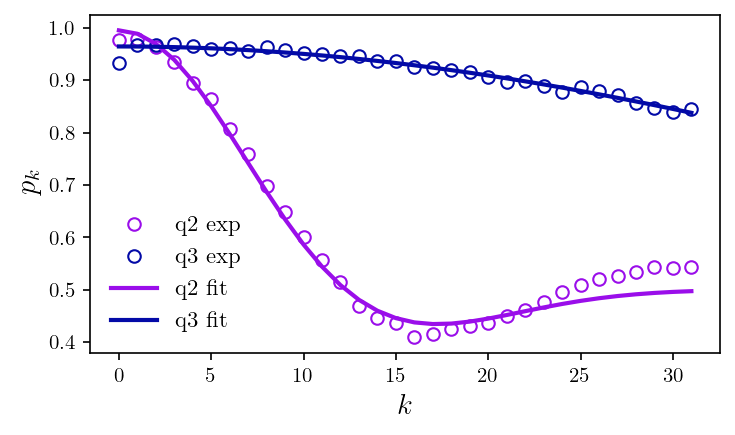

In [4]:
ps_fit = lambda k, eps, sigma, a: (1 + a * np.cos(2*np.pi*eps*k) * np.exp(-sigma*k**2)) / 2

# ── Qubit 2 ──────────────────────────────────────────────────────────────
params2, _ = spopt.curve_fit(ps_fit, kk, ps_all['fttps'][2], p0=(0.01, 0.0035, 1))
eps2, sigma2, a2 = params2
s2   = 1 - a2
eps2 = np.abs(eps2)
print(f'Qubit 2: eps={eps2:.4f}, sigma={sigma2:.6f}, spam={s2:.4f}')

# ── Qubit 3 ──────────────────────────────────────────────────────────────
params3, _ = spopt.curve_fit(ps_fit, kk, ps_all['fttps'][3], p0=(0.01, 0.0035, 1))
eps3, sigma3, a3 = params3
s3   = 1 - a3
eps3 = np.abs(eps3)
print(f'Qubit 3: eps={eps3:.4f}, sigma={sigma3:.6f}, spam={s3:.4f}')

# Quick fit preview
plt.figure(figsize=(5, 3), dpi=150)
plt.plot(kk, ps_all['fttps'][2], color=plot_colors[0], ls='', marker='o', mfc='None', label='q2 exp')
plt.plot(kk, ps_all['fttps'][3], color=plot_colors[2], ls='', marker='o', mfc='None', label='q3 exp')
plt.plot(kk, ps_fit(kk, eps2, sigma2, a2), color=plot_colors[0], lw=2, label='q2 fit')
plt.plot(kk, ps_fit(kk, eps3, sigma3, a3), color=plot_colors[2], lw=2, label='q3 fit')
plt.xlabel('$k$', fontsize=14); plt.ylabel(r'$p_k$', fontsize=14)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout(); plt.show()

## Section 4 – SchWARMA Monte Carlo Simulation

The ARMA filter approximating $1/f^2$ control noise is built from the fitted $\sigma$:
```python
bb, aa = get_pink_arma(1, power=sigma/12)
S = SimpleDephasingSchWARMAFier(bb, aa)
```

Each trajectory draws a correlated noise sequence and propagates the Bloch vector through the FTTPS circuit gate-by-gate using the Lindblad generator:
$$G(\theta,\varepsilon) = \frac{1}{\delta t}\begin{pmatrix} -\alpha & -\beta & 0 \\ \beta & -\alpha & -\theta(1+\varepsilon) \\ 0 & \theta(1+\varepsilon) & -\eta \end{pmatrix}$$

In [5]:
rho_0 = np.array([[1, 0], [0, 0]])
v0    = [np.real(np.trace(rho_0 @ P)) for P in [pauli_x, pauli_y, pauli_z]]

def Gmat_ctrl(theta, alpha, beta, eta, eps):
    """3x3 Lindblad generator for the control-noise simulator."""
    return np.array([[-alpha,        -beta,             0             ],
                     [ beta,         -alpha,            -theta*(1+eps)],
                     [ 0,             theta*(1+eps),    -eta          ]]) / dt

def sim_corr(circ, alpha=1e-10, beta=0, gamma=1e-10, eps=0,
             q=1, spam=0, S=NullSchWARMAFier(), num_MC=1):
    """Monte Carlo LME simulation with correlated control noise (SchWARMA).

    Transpiles the circuit to {id, x, rz, sx} gates, then propagates the
    Bloch vector gate-by-gate. The SchWARMA process S injects a correlated
    noise trajectory eps_t on each X/SX gate.
    """
    t_circ   = qk.transpile(circ, basis_gates=['id', 'x', 'rz', 'sx'],
                             optimization_level=0)
    str_circ = str(t_circ)
    len_circ = str_circ.count('X') + str_circ.count('I')

    noise_trajs = np.reshape(
        S.gen_noise_instances(
            cirq.Circuit([cirq.I.on(cirq.GridQubit(1, 1))] * len_circ),
            num_MC=num_MC),
        (num_MC, len_circ))

    c      = np.array([0, 0, gamma*(2*q - 1)]) / dt
    G_0    = Gmat_ctrl(0, alpha, beta, gamma, 0)
    Ginv_0 = scipy.linalg.inv(G_0)
    eGt_0  = scipy.linalg.expm(G_0 * dt)

    ps_all_mc = []
    for noise_traj in noise_trajs:
        i  = 0
        vt = [np.real(v0)]
        for inst, qargs, _ in t_circ:
            name = inst.name
            if name == 'rz':
                theta_rz = float(inst.params[0])
                c_rz, s_rz = np.cos(theta_rz), np.sin(theta_rz)
                R = np.array([[c_rz, s_rz, 0], [-s_rz, c_rz, 0], [0, 0, 1]])
                new_vt = R @ vt[-1]
                i -= 1
            elif name in ('x', 'sx'):
                angle = np.pi if name == 'x' else np.pi / 2
                G    = Gmat_ctrl(angle, alpha, beta, gamma, eps + noise_traj[i])
                Ginv = scipy.linalg.inv(G)
                eGt  = scipy.linalg.expm(G * dt)
                new_vt = eGt @ vt[-1] + (eGt - np.eye(3)) @ Ginv @ c
            elif name == 'id':
                new_vt = eGt_0 @ vt[-1] + (eGt_0 - np.eye(3)) @ Ginv_0 @ c
            elif name in ('barrier', 'measure'):
                continue
            else:
                print('Unknown gate:', name)
                return []
            i += 1
            vt.append(np.real(np.around(new_vt, 6)).tolist())

        rho_t = (Id + vt[-1][0]*pauli_x + vt[-1][1]*pauli_y + vt[-1][2]*pauli_z) / 2
        if spam:
            rho_t = (1 - spam)*rho_t + spam * pauli_x @ rho_t @ pauli_x
        ps_all_mc.append(np.real(np.trace(rho_t @ rho_0)))
    return ps_all_mc

In [6]:
# ── Qubit 2 simulation ───────────────────────────────────────────────────
bb2, aa2 = get_pink_arma(1, power=sigma2/12)
S2 = SimpleDephasingSchWARMAFier(bb2, aa2)

num_MC  = 50
num_MCr = 10

print('Running FTTPS MC simulation for qubit 2 ...')
ps_fttps2  = [sim_corr(c, alpha=1e-10, beta=0.001, gamma=1e-10,
                        eps=eps2, q=1, spam=s2, S=S2, num_MC=num_MC)
              for c in FTTPS_circs]
ps_mean2   = np.mean(ps_fttps2, axis=1)
ps_std2    = np.std(ps_fttps2,  axis=1)

print('Running R-FTTPS MC simulation for qubit 2 ...')
ps_rfttps2  = [sim_corr(c, alpha=1e-10, beta=0.001, gamma=1e-10,
                         eps=eps2, q=1, spam=s2, S=S2, num_MC=num_MCr)
               for c in rFTTPS_circs]
ps_rmean2   = np.mean(ps_rfttps2, axis=1)
ps_rstd2    = np.std(ps_rfttps2,  axis=1)

# ── Qubit 3 simulation ───────────────────────────────────────────────────
bb3, aa3 = get_pink_arma(1, power=sigma3/12)
S3 = SimpleDephasingSchWARMAFier(bb3, aa3)

print('Running FTTPS MC simulation for qubit 3 ...')
ps_fttps3  = [sim_corr(c, alpha=1e-10, beta=0.001, gamma=1e-10,
                        eps=eps3, q=1, spam=s3/2, S=S3, num_MC=num_MC)
              for c in FTTPS_circs]
ps_mean3   = np.mean(ps_fttps3, axis=1)
ps_std3    = np.std(ps_fttps3,  axis=1)

print('Running R-FTTPS MC simulation for qubit 3 ...')
ps_rfttps3  = [sim_corr(c, alpha=1e-10, beta=0.001, gamma=1e-10,
                         eps=eps3, q=1, spam=s3/2, S=S3, num_MC=num_MCr)
               for c in rFTTPS_circs]
ps_rmean3   = np.mean(ps_rfttps3, axis=1)
ps_rstd3    = np.std(ps_rfttps3,  axis=1)
print('Done.')

Running FTTPS MC simulation for qubit 2 ...
Running R-FTTPS MC simulation for qubit 2 ...
Running FTTPS MC simulation for qubit 3 ...
Running R-FTTPS MC simulation for qubit 3 ...
Done.


## Section 5 – Paper Figure

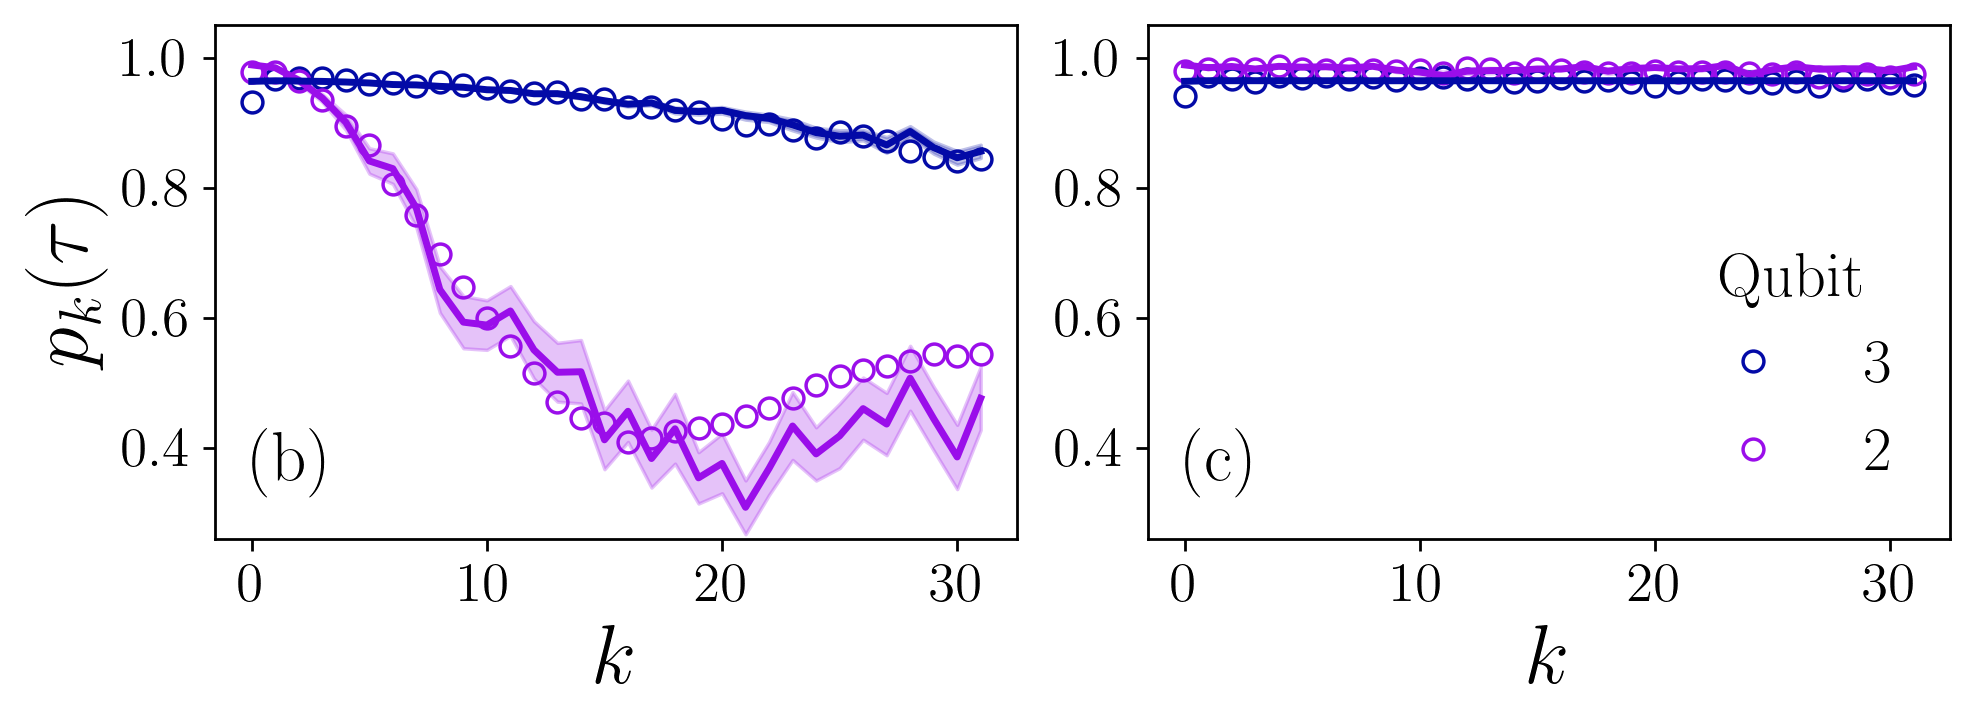

Saved: ../figures/fig_06_correlated_control_noise.pdf


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=250)

# ── Panel (b): FTTPS ──────────────────────────────────────────────────────
ax1.plot(0, 0, color=plot_colors[1], ls='-', lw=3, label=2)
ax1.plot(0, 0, color=plot_colors[2], ls='-', lw=3, alpha=0.6, label=3)
ax1.plot(kk, ps_all_fttps_3, color=plot_colors[2], ls='', lw=3,
         marker='o', mfc='None', alpha=1)
ax1.plot(kk, ps_all_fttps_2, color=plot_colors[0], ls='', lw=3,
         marker='o', mfc='None', alpha=1)
ax1.plot(kk, ps_mean2, color=plot_colors[0], ls='-', lw=2)
ax1.fill_between(kk,
    ps_mean2 - ps_std2 / np.sqrt(num_MC),
    ps_mean2 + ps_std2 / np.sqrt(num_MC),
    alpha=0.25, color=plot_colors[0])
ax1.plot(kk, ps_mean3, color=plot_colors[2], ls='-', lw=2)
ax1.fill_between(kk,
    ps_mean3 - ps_std3 / np.sqrt(num_MC),
    ps_mean3 + ps_std3 / np.sqrt(num_MC),
    alpha=0.25, color=plot_colors[2])
ax1.set_ylabel(r'$p_k(\tau)$', size=24)
ax1.set_xlabel('$k$', fontsize=24)
ax1.set_ylim(0.26, 1.05)
ax1.tick_params(axis='both', labelsize=16)
ax1.text(0, 0.35, '(b)', size=20)

# ── Panel (c): R-FTTPS ────────────────────────────────────────────────────
ax2.plot(kk, ps_all_rfttps_3, color=plot_colors[2], ls='', lw=3,
         marker='o', mfc='None', alpha=1, label=3)
ax2.plot(kk, ps_all_rfttps_2, color=plot_colors[0], ls='', lw=3,
         marker='o', mfc='None', alpha=1, label=2)
ax2.plot(kk, ps_rmean2, color=plot_colors[0], ls='-', lw=2)
ax2.fill_between(kk,
    ps_rmean2 - ps_rstd2 / np.sqrt(num_MCr),
    ps_rmean2 + ps_rstd2 / np.sqrt(num_MCr),
    alpha=0.25, color=plot_colors[0])
ax2.plot(kk, ps_rmean3, color=plot_colors[2], ls='-', lw=2)
ax2.fill_between(kk,
    ps_rmean3 - ps_rstd3 / np.sqrt(num_MCr),
    ps_rmean3 + ps_rstd3 / np.sqrt(num_MCr),
    alpha=0.25, color=plot_colors[2])
ax2.set_xlabel('$k$', fontsize=24)
ax2.set_ylim(0.26, 1.05)
ax2.tick_params(axis='both', labelsize=16)
ax2.legend(frameon=False, fontsize=18, title='Qubit', title_fontsize=18, loc=4)
ax2.text(0, 0.35, '(c)', size=20)

fig.tight_layout()
plt.savefig('../figures/fig_06_correlated_control_noise.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../figures/fig_06_correlated_control_noise.pdf')